# Foresight: Hyperparameter Tuning & Model Explainability (SHAP)
In this final notebook, we will:
1. Take our winning model (Gradient Boosting) and optimize its hyperparameters using `GridSearchCV`.
2. Generate **SHAP (SHapley Additive exPlanations)** values to mathematically explain *why* the model makes its predictions (crucial for operator trust).
3. Export the final optimized model pipeline so our FastAPI backend can use it for real-time predictions.


## 1. Setup & Data Pipeline


In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid", palette="muted")
shap.initjs()

# Load and prepare data
df = pd.read_csv('../data/raw/ai4i2020.csv')
df.columns = [c.strip() for c in df.columns]
df = df.drop(columns=["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"])
df = pd.get_dummies(df, columns=["Type"], drop_first=True)

df["Temp_Diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["Power"] = df["Torque [Nm]"] * (df["Rotational speed [rpm]"] * 2 * np.pi / 60)
df["Tool_Wear_Rate"] = df["Tool wear [min]"] * df["Torque [Nm]"]

X = df.drop(columns=["Machine failure"])
y = df["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


## 2. Hyperparameter Tuning Pipeline
We use an `imblearn` pipeline to ensure SMOTE is only applied to the training folds during cross-validation, preventing data leakage.


In [2]:
print("Setting up the Pipeline...")
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Define a targeted grid search for Gradient Boosting
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [3, 5]
}

# We optimize for 'recall' because missing a failure is much worse than a false alarm
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='recall', n_jobs=-1, verbose=2)

print("Running Grid Search...")
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Recall: {grid_search.best_score_:.3f}")

best_model = grid_search.best_estimator_


Setting up the Pipeline...
Running Grid Search...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
Best Cross-Validation Recall: 0.937


## 3. Evaluating the Optimized Model


--- Optimized Gradient Boosting ---
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1932
           1       0.34      0.93      0.50        68

    accuracy                           0.94      2000
   macro avg       0.67      0.93      0.73      2000
weighted avg       0.97      0.94      0.95      2000



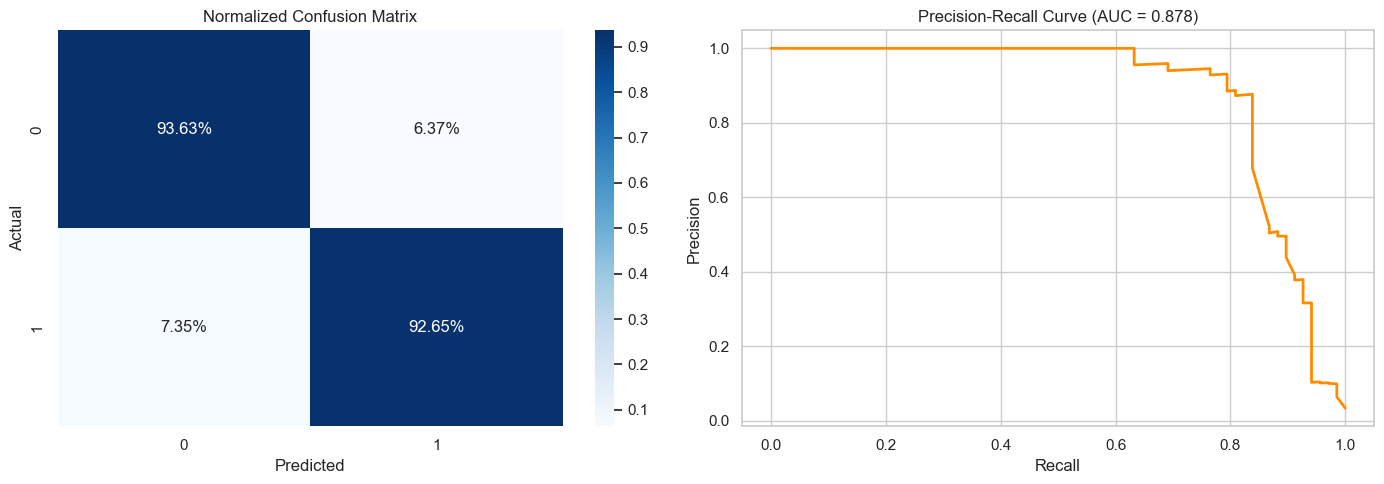

In [3]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("--- Optimized Gradient Boosting ---")
print(classification_report(y_test, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues", ax=axes[0])
axes[0].set_title("Normalized Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# PR Curve
pr_vals, rc_vals, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(rc_vals, pr_vals)
axes[1].plot(rc_vals, pr_vals, color='darkorange', lw=2)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"Precision-Recall Curve (AUC = {pr_auc:.3f})")

plt.tight_layout()
plt.show()


## 4. Model Explainability (SHAP)
SHAP values allow us to see inside the 'black box' of the model. The Summary Plot shows which features drive the model to predict a failure.


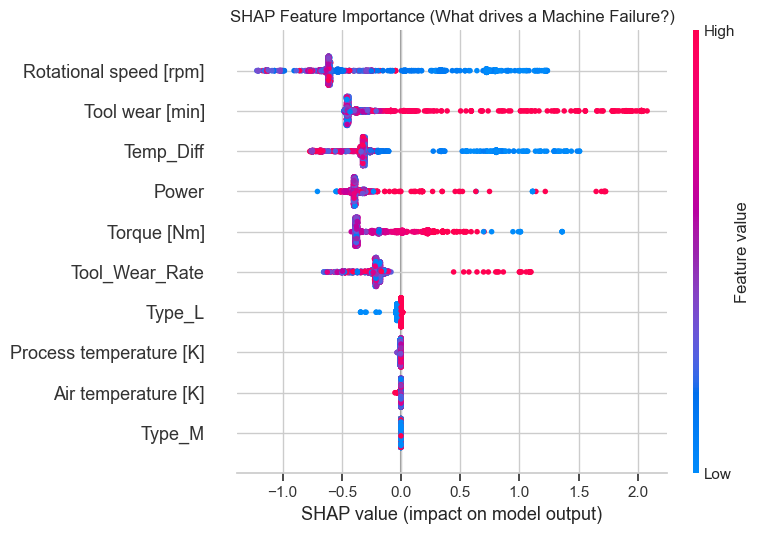

In [4]:
# Extract the trained model and the scaler to generate SHAP values
gb_model = best_model.named_steps['classifier']
scaler = best_model.named_steps['scaler']
X_test_scaled = scaler.transform(X_test)

# Initialize the SHAP Explainer
explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_test_scaled)

# 1. SHAP Summary Plot
plt.figure(figsize=(10, 8))
plt.title("SHAP Feature Importance (What drives a Machine Failure?)")
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.tight_layout()
plt.show()


### Single Prediction Breakdown (Local Explainability)
This plot explains a *single* machine's prediction. We will find a machine that actually failed, and ask SHAP to explain exactly *why* the model flagged it.


Explaining prediction for Machine at test index: 17


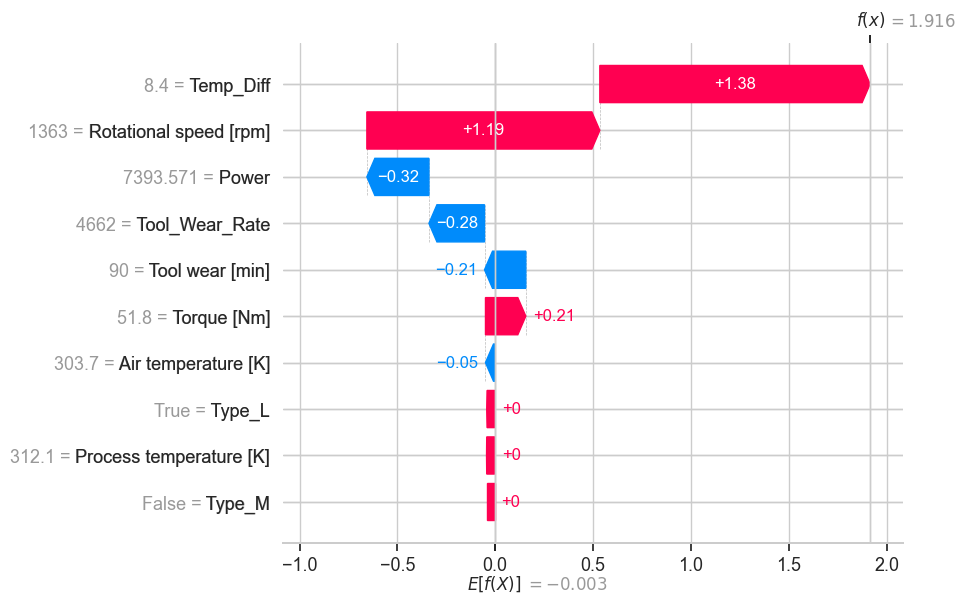

In [5]:
# Find a true positive (a machine that failed and we predicted it would fail)
failed_indices = np.where((y_test == 1) & (y_pred == 1))[0]
if len(failed_indices) > 0:
    idx = failed_indices[0]
    print(f"Explaining prediction for Machine at test index: {idx}")
    
    # Ensure base_value is a scalar float
    base_val = explainer.expected_value[0] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    if isinstance(base_val, np.ndarray):
        base_val = base_val.item()
        
    # SHAP Force Plot for a single instance
    plt.figure(figsize=(10, 3))
    shap.waterfall_plot(shap.Explanation(values=shap_values[idx], 
                                         base_values=float(base_val), 
                                         data=X_test.iloc[idx], 
                                         feature_names=X_test.columns))
    plt.show()
else:
    print("No true positives found to explain.")


## 5. Exporting the Pipeline
We save the entire optimized pipeline (Scaler + SMOTE + Tuned Model) so the FastAPI backend can load it directly.


In [6]:
model_dir = Path('../model')
model_dir.mkdir(exist_ok=True)
model_path = model_dir / "foresight_model.joblib"

joblib.dump(best_model, model_path)
print(f"Optimized model successfully exported to: {model_path}")


Optimized model successfully exported to: ..\model\foresight_model.joblib
